In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from numba.cuda.cudadrv.devicearray import lru_cache

import components.broadcast_components.WZ_models.wz_quant_ANN
import components.broadcast_components.WZ_models.wz_quant_RNN
import components.other_utilities.brent_wz_models
from make_basic_rnn_model import utilities
import importlib

# ----------------------------------------------------------------
torch.set_float32_matmul_precision('medium')
import logging
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)
import warnings
warnings.filterwarnings("ignore", message="Starting from v1.9.0, `tensorboardX` has been removed")
warnings.filterwarnings("ignore", message="You defined a `validation_step` but have no `val_dataloader`")
warnings.filterwarnings("ignore", message="Consider setting `persistent_workers=True` in 'train_dataloader'")
warnings.filterwarnings("ignore", message="The 'val_dataloader' does not have")

In [9]:
import random

random.seed(10)
torch.manual_seed(10)
np.random.seed(10)

temp = np.random.normal(0, np.sqrt(1), 2_000_000, ).astype(np.float32)
y = temp + np.random.normal(0, np.sqrt(0.01), 2_000_000, ).astype(np.float32)
side_info_data = [temp]

importlib.reload(utilities)
y, side_info_data = utilities.prep_data(y, side_info_data, normalize=False)
side_info_variance, noise_variance = utilities.get_data_var(y, side_info_data)

temp = (y>=-3)+(y<=3)
y=y[temp]
y = np.round(y*5)/5
side_info_data = [y]

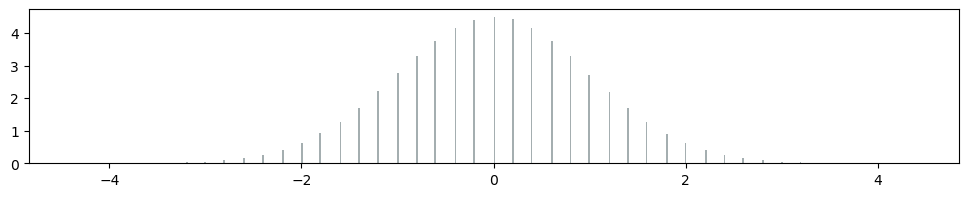

In [10]:
plt.figure(figsize=(12, 2))
plt.hist(y, density=True, alpha=0.5, bins=500)
if len(side_info_data):
    plt.hist(side_info_data[0], 500, density=True, alpha=0.2)
# plt.ylim(0,5)
# plt.xlim(-2,2)
plt.show()

In [11]:
importlib.reload(components.broadcast_components.WZ_models.wz_quant_ANN)
importlib.reload(components.broadcast_components.WZ_models.wz_quant_RNN)
importlib.reload(components.other_utilities.brent_wz_models)
from components.broadcast_components.WZ_models.wz_quant_ANN import WZQuantizer
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_RNN
from components.broadcast_components.WZ_models.wz_quant_RNN import PL_EncoderDecoder_ANN

# seed set
import random
random.seed(10)
torch.manual_seed(10)
np.random.seed(10)

class test(PL_EncoderDecoder_ANN):
    def __init__(self, y):
        self.coding_model = None
        self.bin_count_ = len(np.unique(self.encode_net(torch.tensor(y, dtype=torch.float32))))
        super(test, self).__init__(1, 1)

    @property
    def bin_count(self):
        return self.bin_count_

    def get_prior_and_softcodes_net(self, grad_vector, side_info=None):
        temp = torch.round(grad_vector*5).abs()
        freq = torch.stack(torch.unique(temp, return_counts=True)).T
        for f in freq:
            temp[f[0]==temp] = f[1]/len(temp)

        return temp, temp

    def encode_net(self, grad_vector):
        return torch.round(grad_vector*5).abs().squeeze()

    def decode_net(self, bins, side_info:torch.Tensor):
        return (bins.to(torch.int16)/5)* side_info.squeeze().sign().to(torch.int16)+0.01


wz_model = test(y).to(torch.float32)

wz_quantizer = WZQuantizer(wz_model, train_sample_size=200_000, count_side_info_data=1, enable_progress_bar=True)


In [ ]:
importlib.reload(utilities)
mse, mspe, real_bit_rate, prior_bit_rate, softcodes_bit_rate, alt_real_bits = utilities.get_metrics(y, side_info_data, wz_quantizer, )
f'{mse=:0.5f}, {mspe=:0.3f}, {real_bit_rate=:0.3f}, {prior_bit_rate=:0.3f}, {softcodes_bit_rate=:0.3f}, {alt_real_bits=:0.3f}'